# EDA Titanic

## 1. 데이터셋 개요

목적: 1912년 타이타닉호 침몰 사고에서 승객의 생존 여부를 예측하는 것이다.

문제 유형: 이진 분류(Binary Classification) 문제이다. 생존(1) 또는 사망(0)을 예측한다.

데이터 규모:

* 훈련 데이터: 891명의 승객 정보
* 테스트 데이터: 418명의 승객 정보

## 2. 주요 변수 (Features) 설명

### 2.1 기본 정보

* PassengerId: 승객 고유 번호다
* Survived: 생존 여부 (0 = 사망, 1 = 생존) - 타겟 변수다
* Name: 승객 이름이다

### 2.2 승객 특성

* Pclass: 객실 등급 (1 = 1등석, 2 = 2등석, 3 = 3등석)
* Sex: 성별 (male, female)
* Age: 나이 (일부 결측치가 있다)

### 2.3 가족 관계

* SibSp: 함께 탑승한 형제자매 및 배우자 수다
* Parch: 함께 탑승한 부모 및 자녀 수다

### 2.4 티켓 정보

* Ticket: 티켓 번호다
* Fare: 요금이다
* Cabin: 객실 번호다 (많은 결측치가 있다)
* Embarked: 승선 항구 (C = Cherbourg, Q = Queenstown, S = Southampton)

## 3. 데이터 특징

### 3.1 결측치 (Missing Values)

* Age: 약 20%의 결측치가 있다
* Cabin: 약 77%의 결측치가 있다
* Embarked: 소수의 결측치가 있다

### 3.2 알려진 생존 패턴

* 성별: 여성의 생존율이 높았다 ("여성과 어린이 먼저" 원칙)
* 객실 등급: 1등석 승객의 생존율이 높았다
* 나이: 어린이의 생존율이 상대적으로 높았다
* 가족: 혼자 탑승한 경우보다 가족과 함께 탑승한 경우가 복잡한 패턴을 보인다

## 4. 활용 방법

이 데이터셋으로 다음을 학습할 수 있다.

1. 데이터 전처리: 결측치 처리, 범주형 변수 인코딩
2. 탐색적 데이터 분석(EDA): 시각화를 통한 패턴 발견
3. 특징 공학(Feature Engineering): 새로운 변수 생성 (예: 가족 크기, 호칭 추출)
4. 모델링: 로지스틱 회귀, 랜덤 포레스트, XGBoost 등 다양한 알고리즘 적용
5. 모델 평가: 정확도, 정밀도, 재현율 등 평가 지표 이해

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Mac 기준 한글 폰트 설정
plt.rcParams["font.family"] = "AppleGothic"
# 마이너스 부호 깨짐 문제 방지
plt.rcParams["axes.unicode_minus"] = False

# 01. 데이터 수집 및 로드

In [4]:
df = pd.read_csv('data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 02. 데이터 구조 및 변수 이해

In [7]:
print(df.shape)
print(df.dtypes)
df.info()

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2)

# 03. 데이터 요약 및 기술통계

In [9]:
# 수치형 데이터 요약
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
# 범주형 데이터 요약
df.describe(include=['string'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [14]:
# 범주형 데이터 value_counts() 활용
# print(df['Pclass'].value_counts()) # 아래와 동일한 방법
print(df.value_counts('Pclass'))
print(df.value_counts('Sex'))
print(df.value_counts('Embarked'))
print(df.value_counts('Survived'))
print(df.value_counts('SibSp'))
print(df.value_counts('Parch'))

Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Survived
0    549
1    342
Name: count, dtype: int64
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


# 04. 중복 값, 결측치, 이상치 탐지 및 전처리

In [20]:
print(df.duplicated().sum())               # 중복된 행 확인 -> 모든 컬럼 값이 동일한 행이 있는지
print(df.duplicated('PassengerId').sum())   # 모두 식별 가능한 레코드인지
print(df.duplicated('Name').sum())         # 이름은 중복 상관 없는 속성

0
0
0


In [21]:
print(df.isna().sum())      # 결측치 행 제거 or 값 대치(0, 평균값, 중앙값, ...)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


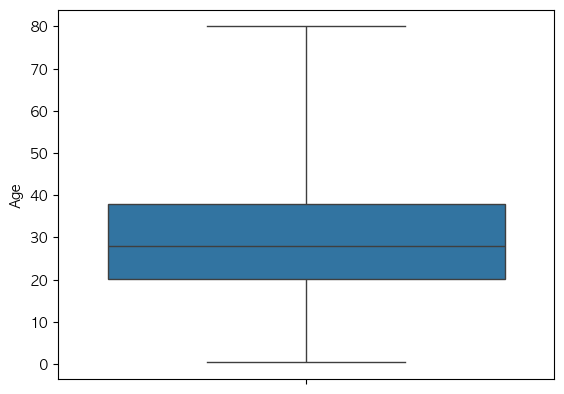

In [28]:
# 이상치 탐지
# whis=1.5 (IQR 1.5배 이상) 기본 값
sns.boxplot(df, y="Age", whis=2.5)
plt.show()

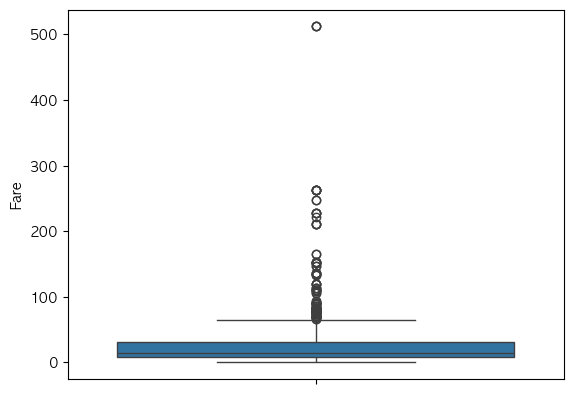

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


TypeError: 'DataFrame' object is not callable

In [32]:
# Fare
sns.boxplot(df, y="Fare")
plt.show()

# 데이터 확인 (비싼 요금으로 탑승했으나 3등석인 데이터가 있지는 않은지?)
display(df[df['Fare'] > 500])
display(df(df['Fare'] > 200) & (df['Pclass'] == 3))

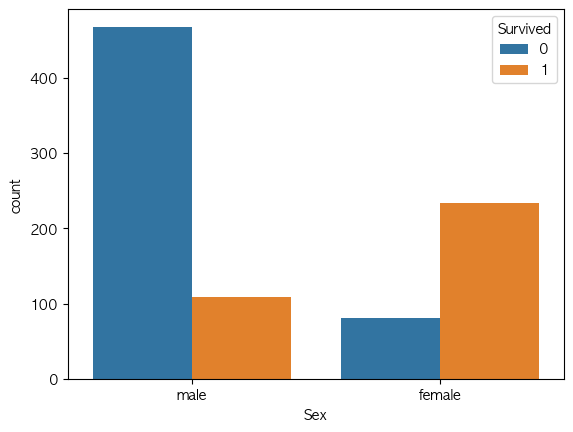

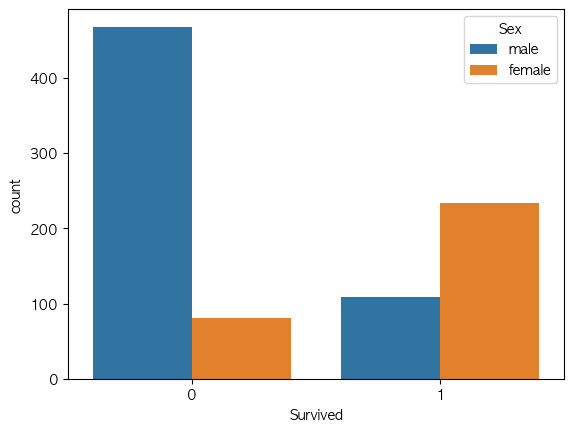

In [ ]:
# 성별(범주형)과 생존여부(범주형)의 관계
sns.countplot(data=df, x='Sex', hue='Survived')
plt.show()

sns.countplot(data=df, x='Survived', hue='Sex')
plt.show()
# 여성의 생존 비율이 남성보다 높게 나타난다.
# 구조 과정에서 여성 우선 구조가 이루어졌음을 시사한다.

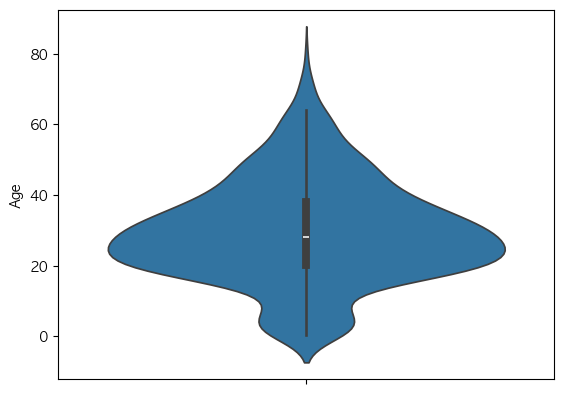

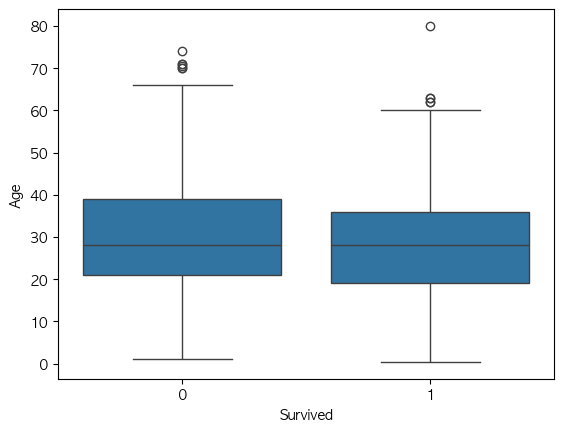

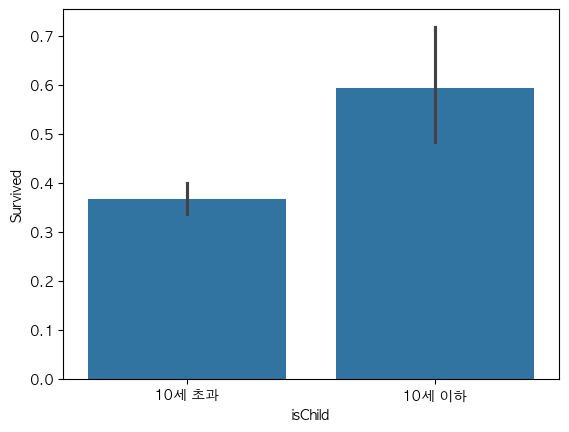

In [ ]:
# 나이(수치형)
sns.violinplot(data=df, y='Age')
plt.show()

# 나이 분포에서 특정 구간에 집중 된 경향이 보임
# 생존 여부와 함께 비교해보며 관련 있는지 확인
sns.boxplot(data=df, x='Survived', y='Age')
plt.show()

# 어린이 여부(10세 이하) 기준 생존율 비교
df['isChild'] = (df['Age'] <= 10).astype(int)    # (0 or 1)
sns.barplot(data=df, x='isChild', y='Survived')
plt.xticks([0, 1], ["10세 초과", "10세 이하"])
plt.show()
# 10세 이하의 생존율이 높은 것을 확인할 수 있다.
# 역시 구조 과정에서 우선 구조 되었음을 시사한다.

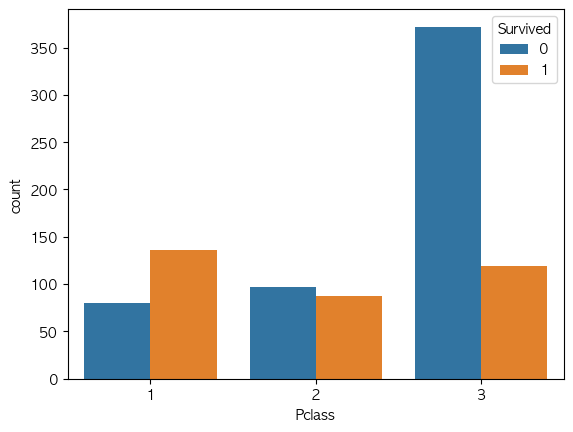

In [ ]:
# 선실 등급별 생존율 시각화
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.show()
# 1등실은 생존 비율이 높고, 3등실은 사망 비율이 높은 경향을 보임
# 객실 등급이 생존과 관련 있을 가능성을 확인할 수 있다.

# 06. 변수간 관계 시각화

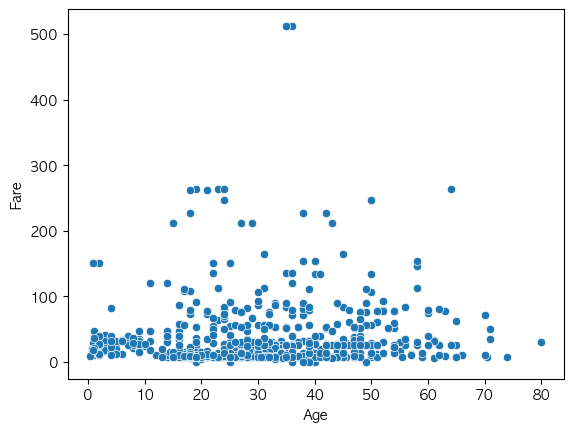

In [45]:
# 나이, 요금간의 산포도
sns.scatterplot(df, x='Age', y='Fare')
plt.show()

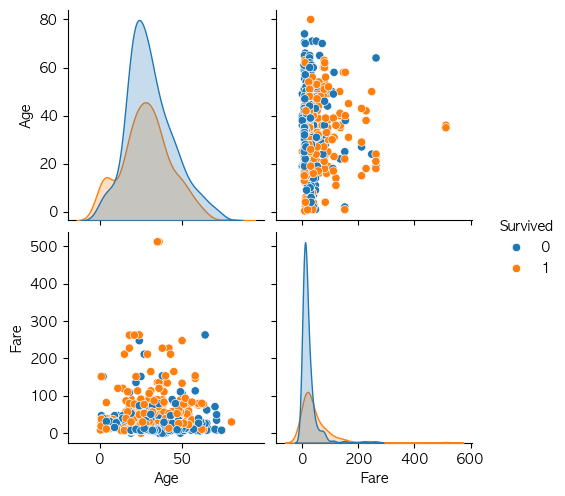

In [50]:
# pairplot 으로 모든 수치형 데이터간 관계를 한 번에 확인
# sns.pairplot(df[['Age', 'Fare']])
sns.pairplot(df[['Age', 'Fare', 'Survived']], hue='Survived')
plt.show()

# 07. 상관관계 및 교차분석
- 연속형 데이터: 상관계수
- 범주형 데이터: 교차표

In [51]:
corr_mat = df.corr(numeric_only=True)    # 수치형만 구할 때 의미가 있어, 수치형에 대한 것만 구해봄

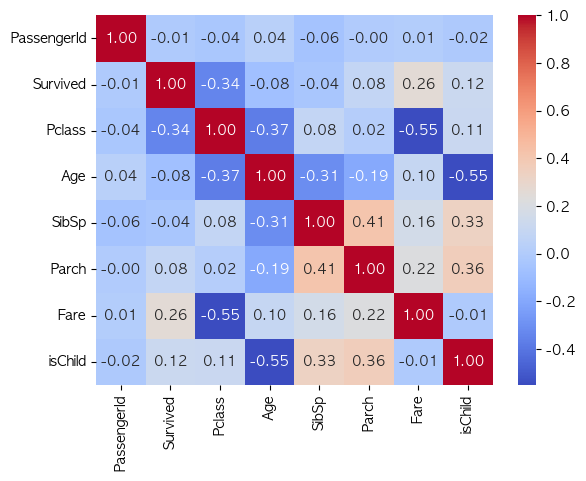

In [54]:
# 히트맵 시각화
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [ ]:
# 교차표 (범주형)
pd.crosstab(df['Sex'], df['Survived'])

In [56]:
# 범주형 데이터 간 생존율 분석
pivot_df1 = df.pivot_table(index='Sex', columns='Pclass', values='Survived', aggfunc='mean')
pivot_df2 = df.pivot_table(index='Embarked', columns='Pclass', values='Survived', aggfunc='mean')
display(pivot_df1)
display(pivot_df2)

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


Pclass,1,2,3
Embarked,,,
C,0.694118,0.529412,0.378788
Q,0.500000,0.666667,0.375000
S,0.582677,0.463415,0.189802


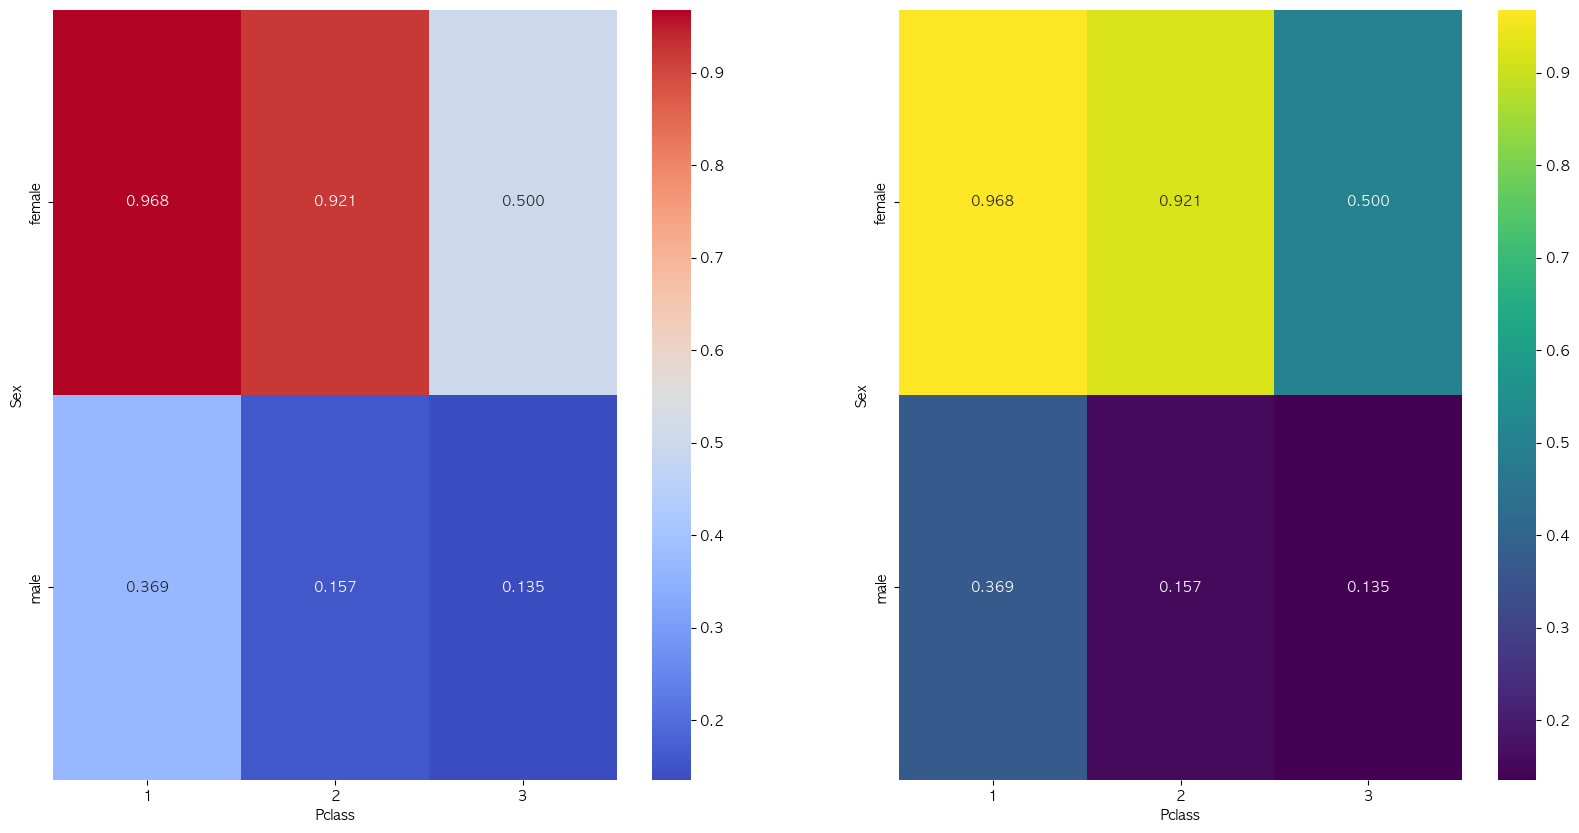

In [60]:
# 히트맵 시각화
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.heatmap(pivot_df1, annot=True, fmt='.3f', ax=ax[0],cmap='coolwarm')
sns.heatmap(pivot_df1, annot=True, fmt='.3f', ax=ax[1],cmap='viridis')
plt.show()